In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

## Dataset

In [3]:
x_raw = np.array([
    ["Pointy", "Round", "Present"],
    ["Floppy", "NotRound", "Present"],
    ["Floppy", "Round", "Absent"],
    ["Pointy", "NotRound", "Present"],
    ["Pointy", "Round", "Present"],
    ["Pointy", "Round", "Absent"],
    ["Floppy", "NotRound", "Absent"],
    ["Pointy", "Round", "Absent"],
    ["Floppy", "Round", "Absent"],
    ["Floppy", "Round", "Absent"]
])

# Target: 1 = Cat, 0 = Not Cat
y = np.array([1, 1, 0, 0, 1, 1, 0, 1, 0, 0])

In [4]:
## one-hot encoding
encoder = OneHotEncoder(sparse_output = False)
x_encoded = encoder.fit_transform(x_raw)
feature_names = encoder.get_feature_names_out()

## Model

In [5]:
xgb = XGBClassifier(
    n_estimators = 50,
    max_depth = 3,
    learning_rate = 0.1,
    objective = "binary:logistic",
    eval_metric = "logloss",
    random_state = 42
)
xgb.fit(x_encoded, y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Prediction

In [6]:
y_pred = xgb.predict(x_encoded)
print("Accuracy: ", accuracy_score(y, y_pred))

Accuracy:  0.8


## Plot: Feature importance

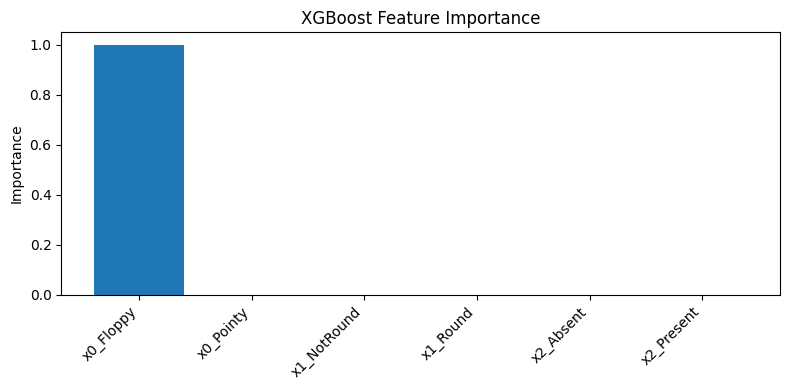

In [7]:
plt.figure(figsize = (8,4))
plt.bar(feature_names, xgb.feature_importances_)
plt.xticks(rotation = 45, ha = "right")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

## Example Prediction

In [8]:
new_animal = np.array([["Pointy", "Round", "Present"]])
new_animal_encoded = encoder.transform(new_animal)

print("Prediction: ", xgb.predict(new_animal_encoded))

Prediction:  [1]
